# Chapter 04

1. 糖尿病数据
    1.1 数据加载

    1.2 划分数据

    1.3 基础线性回归

    1.4 预测值与真实值对比图

2. 波士顿房价数据
    2.1 数据加载

    2.2 划分数据

    2.3 基础线性回归

    2.4 数据归一化

    2.5 基础线性回归（归一化）

    2.6 未归一化与归一化对比

    2.7 岭回归 - L2正则化

    2.8 岭回归不同 alpha 值的效果对比

    2.9 Lasso回归 - L1正则化

    2.10 模型对比（可视化）

In [797]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



## 1. 糖尿病数据

### 1.1 数据加载

In [798]:
# 1. 下载数据集
diabetes = load_diabetes()
# diabetes
X = diabetes.data          # 特征矩阵 (442, 10)
y = diabetes.target        # 目标变量 (442,)

print("数据集形状:", X.shape)
print("特征名称:", diabetes.feature_names)

数据集形状: (442, 10)
特征名称: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [799]:
diabetes.data.shape

(442, 10)

In [800]:
print(type(diabetes.data))

<class 'numpy.ndarray'>


In [801]:
diabetes.target.shape

(442,)

In [802]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [803]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [804]:
X=diabetes.data
y=diabetes.target
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

### 1.2 划分数据

将数据按 80% 训练，20% 测试划分。

In [805]:
# 2. 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 1.3 基础线性回归

In [806]:
# 3. 建立模型
model = LinearRegression()

# 4. 训练
model.fit(X_train, y_train)

# 5. 预测
y_pred = model.predict(X_test)

# 6. 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 2900.1936284934804
R²: 0.4526027629719196


### 1.4 预测值与真实值对比图


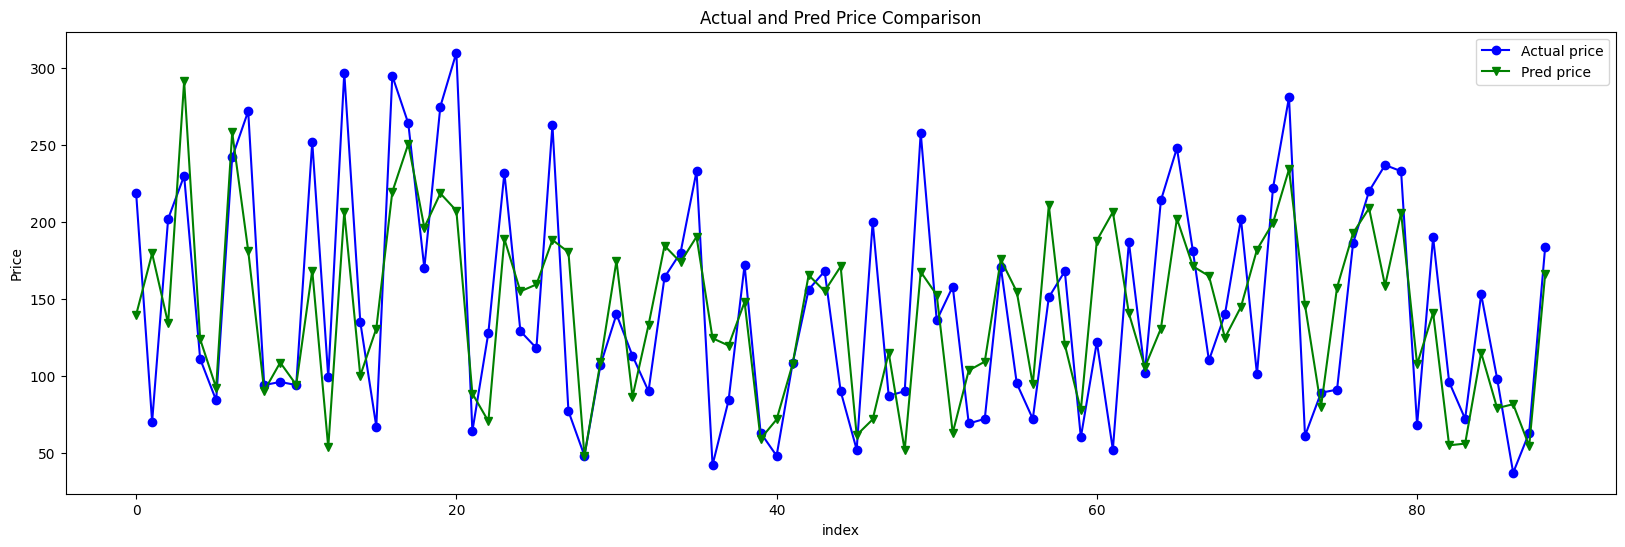

In [807]:
# 绘制预测值与真实值图

import matplotlib.pyplot as plt
plt.figure(figsize=(20, 6))# 调整输出的图片大小
# plt.rcParams['font.sans-serif'] = [u'SimHei']
# plt.rcParams['axes.unicode_minus'] = False
plt.plot(y_test, 'o-',color="b", label="Actual price",)  # 颜色表示
plt.plot(y_pred, 'v-',color='g', label="Pred price")
plt.xlabel("index")  # x轴命名表示
plt.ylabel("Price")  # y轴命名表示
plt.title("Actual and Pred Price Comparison")
plt.legend()  # 增加图例
plt.show()  # 显示图片

## 2. 波士顿数据

In [808]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

### 2.1 数据加载

In [809]:
# 1️⃣ Load the dataset
# fetch_openml replaces load_boston (deprecated)
boston = fetch_openml(name="boston", version=1, as_frame=True)
X = boston.data
y = boston.target

# CRIM--城镇人均犯罪率                                                              ------【城镇人均犯罪率】
# ZN - 占地面积超过25,000平方英尺的住宅用地比例。               ------【住宅用地所占比例】
# INDUS - 每个城镇非零售业务的比例。                                      ------【城镇中非商业用地占比例】
# CHAS - Charles River虚拟变量（如果是河道，则为1;否则为0  ------【查尔斯河虚拟变量，用于回归分析】
# NOX - 一氧化氮浓度（每千万份）                                             ------【环保指标】
# RM - 每间住宅的平均房间数                                                      ------【每栋住宅房间数】
# AGE - 1940年以前建造的自住单位比例                                     ------【1940年以前建造的自住单位比例 】
# DIS -波士顿的五个就业中心加权距离                                        ------【与波士顿的五个就业中心加权距离】
# RAD - 径向高速公路的可达性指数                                             ------【距离高速公路的便利指数】
# TAX - 每10,000美元的全额物业税率                                          ------【每一万美元的不动产税率】
# PTRATIO - 城镇的学生与教师比例                                             ------【城镇中教师学生比例】
# B - 1000（Bk - 0.63）^ 2其中Bk是城镇黑人的比例                   ------【城镇中黑人比例】
# LSTAT - 人口状况下降％                                                            ------【房东属于低等收入阶层比例】
# MEDV - 自有住房的中位数报价, 单位1000美元                         ------【自住房屋房价中位数】

In [810]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [811]:
type(X)

pandas.core.frame.DataFrame

In [812]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

### 2.2 划分数据

将数据按 80% 训练，20% 测试划分。

In [813]:
X=np.array(X)
y=np.array(y)

# 2. 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




### 2.3 基础线性回归

In [814]:
# 3. 建立模型
model = LinearRegression()

# 4. 训练模型
model.fit(X_train, y_train)

# 5. 预测
y_pred = model.predict(X_test)

# 6. 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 24.291119474973602
R2: 0.6687594935356309


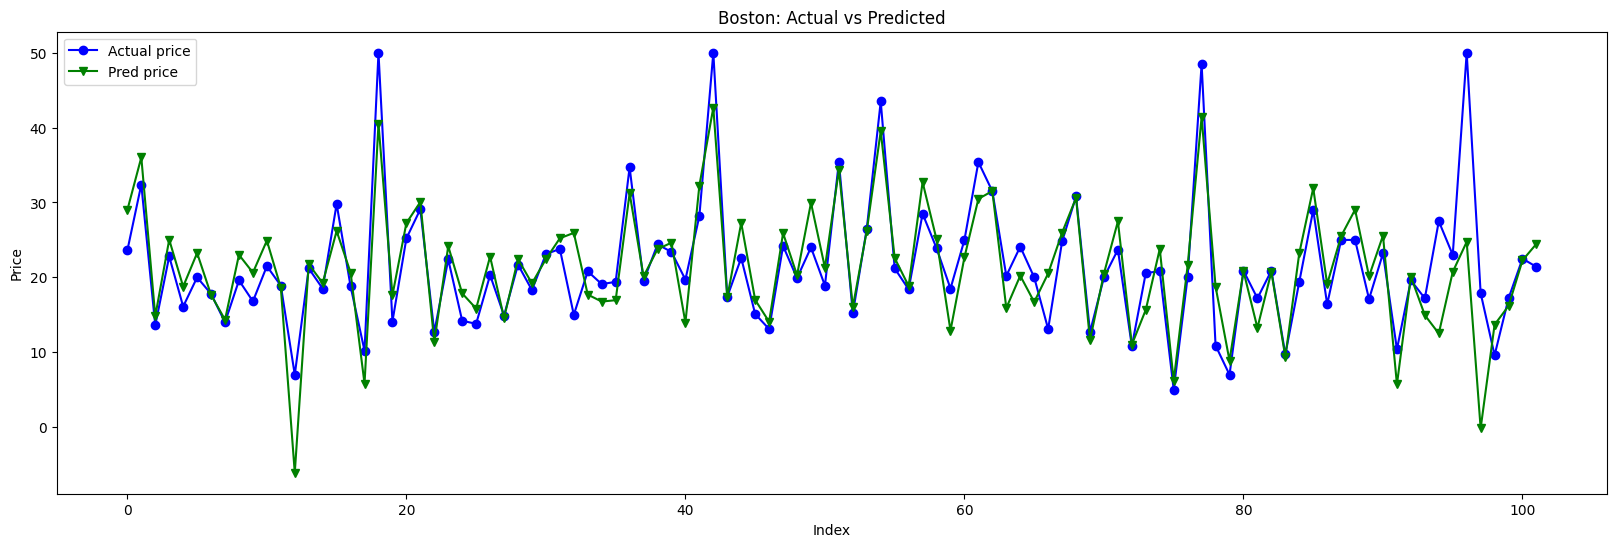

In [815]:
plt.figure(figsize=(20, 6))
plt.plot(y_test, 'o-', color="b", label="Actual price")
plt.plot(y_pred, 'v-', color='g', label="Pred price") # 基础预测结果
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Boston: Actual vs Predicted")
plt.legend()
plt.show()

### 2.2 数据归一化

- 当特征尺度差异很大时（如CRIM在0-90，RM在3-9），梯度下降会变得困难
- 归一化后，所有特征在相同尺度上，参数更新更均衡
- 结论：归一化不影响最终预测结果，只加速训练过程

In [816]:
# 对不同尺度的特征做归一化，避免大尺度特征主导梯度更新
scaler = StandardScaler()

# 训练集：拟合+转换，学习数据均值/方差（避免数据泄露
X_train_scaled = scaler.fit_transform(X_train)

# 测试集：仅转换，复用训练集的均值/方差
X_test_scaled = scaler.transform(X_test)

print(f"归一化后训练集特征：{X_train_scaled.shape} | 测试集特征：{X_test_scaled.shape}")

归一化后训练集特征：(404, 13) | 测试集特征：(102, 13)


### 2.3 基础线性回归（归一化）


In [817]:
model_linear_scaled = LinearRegression()  # 同未归一化模型，保证对比公平
model_linear_scaled.fit(X_train_scaled, y_train)  # 基于最小二乘法求解最优w0-wd
y_pred_linear_scaled = model_linear_scaled.predict(X_test_scaled)  # 测试集预测


# 计算归一化模型的MSE/R²
mse_linear_scaled = mean_squared_error(y_test, y_pred_linear_scaled)
r2_linear_scaled = r2_score(y_test, y_pred_linear_scaled)

# 打印归一化模型结果+对比
print("基础线性回归（归一化）")
print("实际房价:", y_test[:5])
print("预测房价:", y_pred_linear_scaled[:5])
print("均方误差(MSE)：" + str(round(mse_linear_scaled, 4))) # 越小越好
print("决定系数(R²)：" + str(round(r2_linear_scaled, 4))) # 越接近1越好

基础线性回归（归一化）
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]
均方误差(MSE)：24.2911
决定系数(R²)：0.6688


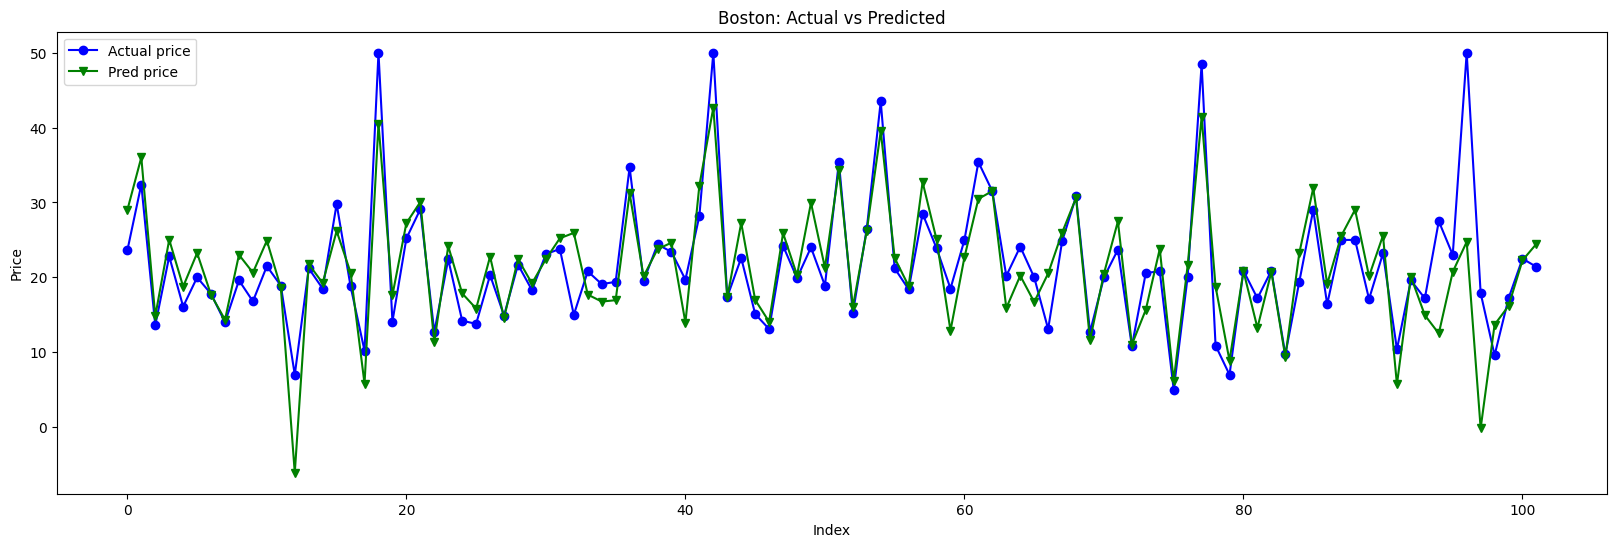

In [818]:
plt.figure(figsize=(20, 6))
plt.plot(y_test, 'o-', color="b", label="Actual price")
plt.plot(y_pred_linear_scaled, 'v-', color='g', label="Pred price")
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Boston: Actual vs Predicted")
plt.legend()
plt.show()

### 2.4 未归一化与归一化

In [819]:
# 核心对比总结（直观展示差异）
print("未归一化 与 归一化 对比")
print("MSE差异：" + str(round(abs(mse - mse_linear_scaled), 6))) # 几乎为0
print("R²差异：" + str(round(abs(r2 - r2_linear_scaled), 6))) # 几乎为0

未归一化 与 归一化 对比
MSE差异：0.0
R²差异：0.0


可视化

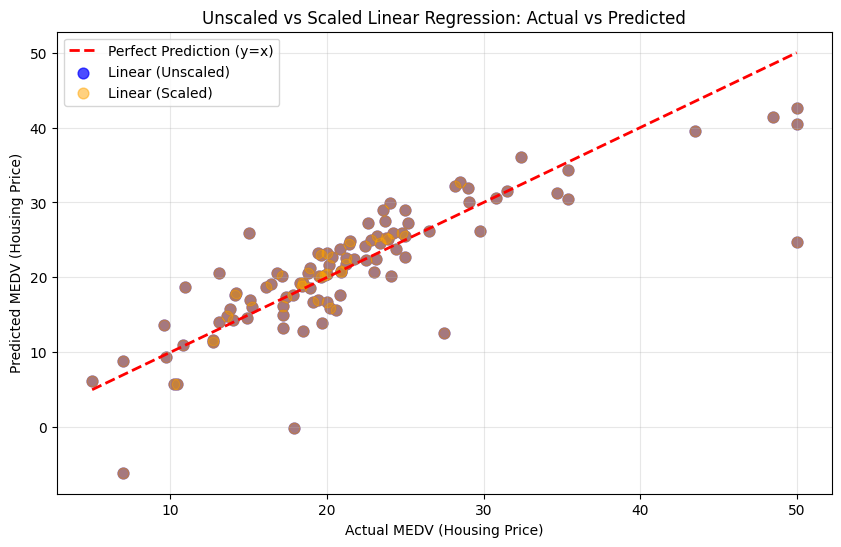

In [820]:
# 绘制未归一化/归一化预测值 vs 实际值对比图
plt.figure(figsize=(10, 6))
# 完美预测线（红色虚线）
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction (y=x)', linewidth=2)
# 未归一化预测结果（蓝色）
plt.scatter(y_test, y_pred, color='blue', label='Linear (Unscaled)', alpha=0.7, s=60)
# 归一化预测结果（橙色）
plt.scatter(y_test, y_pred_linear_scaled, color='orange', label='Linear (Scaled)', alpha=0.5, s=60)

# 标注信息
plt.xlabel('Actual MEDV (Housing Price)')
plt.ylabel('Predicted MEDV (Housing Price)')
plt.title('Unscaled vs Scaled Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

结论

归一化仅加速模型训练，不改变最终预测效果

### 2.5 岭回归 - L2正则化


岭回归损失函数：

\[
E(w) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - w^T x^{(i)})^2 + \lambda \|w\|^2
\]

其中 \(\|w\|^2 = w_1^2 + w_2^2 + \dots + w_d^2\)

为什么加正则项？
- 惩罚大的权重，让所有参数尽量小
- 防止模型过于复杂，减少过拟合风险
- \(\lambda\) 越大，正则化惩罚越强

In [821]:
# 构建岭回归模型（L2正则）
model_ridge = Ridge(alpha=1.0)  # alpha=λ，正则化系数，默认1.0（可调整）
model_ridge.fit(X_train_scaled, y_train)  # 岭回归训练（基于梯度下降）
y_pred_ridge = model_ridge.predict(X_test_scaled)  # 测试集预测

# 计算岭回归的MSE/R²
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 打印岭回归评估结果
print("岭回归 - L2正则")
print("实际房价:", y_test[:5])
print("预测房价:", y_pred_ridge[:5])
print("均方误差(MSE)：" + str(round(mse_ridge, 4)))
print("决定系数(R²)：" + str(round(r2_ridge, 4)))


岭回归 - L2正则
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [28.97307596 35.97429236 14.93254622 25.02130988 18.76446192]
均方误差(MSE)：24.3129
决定系数(R²)：0.6685


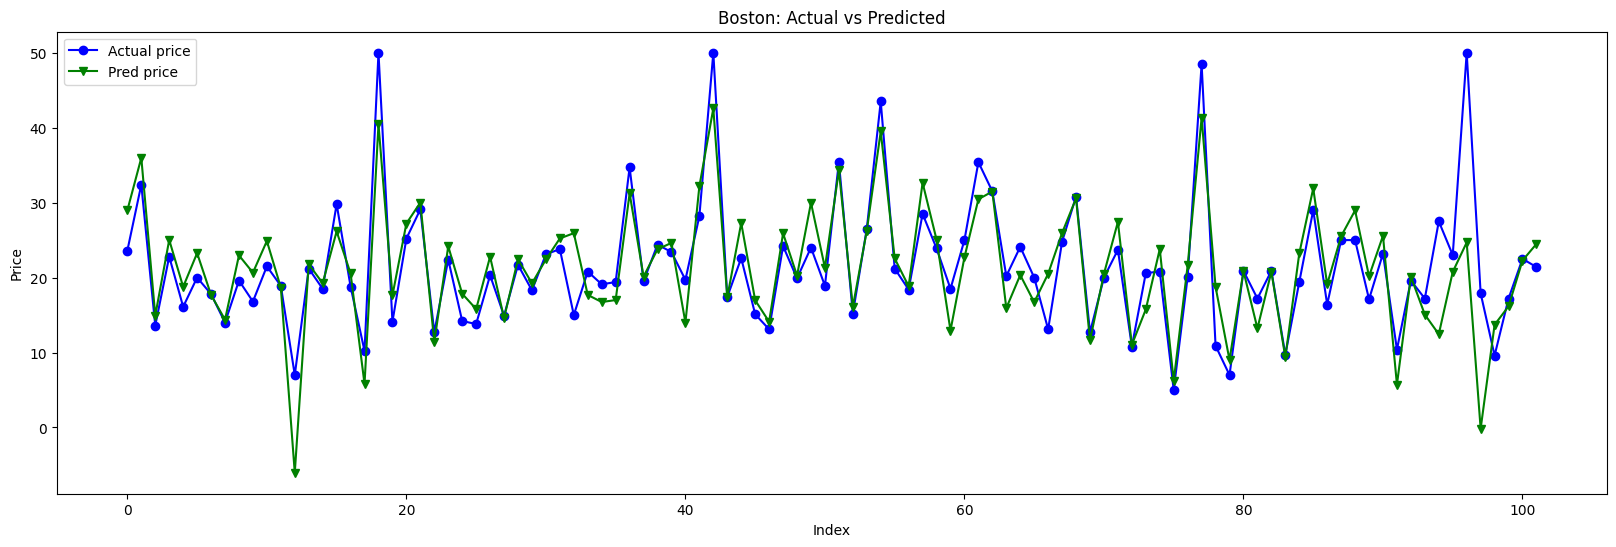

In [822]:
plt.figure(figsize=(20, 6))
plt.plot(y_test, 'o-', color="b", label="Actual price")
plt.plot(y_pred_ridge, 'v-', color='g', label="Pred price")
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Boston: Actual vs Predicted")
plt.legend()
plt.show()

In [823]:
# 岭回归 vs 基础线性回归对比
print("岭回归 与 基础线性回归对比")
print("MSE变化：" + str(round(mse_linear_scaled - mse_ridge, 4))) # 负数=岭回归MSE更小，效果更好
print("R²变化：" + str(round(r2_ridge - r2_linear_scaled, 4))) # 正数=岭回归R²更高，拟合更好

岭回归 与 基础线性回归对比
MSE变化：-0.0218
R²变化：-0.0003


L2正则惩罚大权重，有效降低过拟合风险，模型泛化能力提升

### 2.6 岭回归不同 alpha 值的效果对比

调参规律：
- alpha 过小 → 正则化效果弱，接近线性回归
- alpha 过大 → 正则化过强，导致欠拟合

In [824]:
# 岭回归不同alpha系数效果对比
print("岭回归不同alpha系数效果对比")
print("alpha值      MSE        R²")

# alpha=0.01 正则化弱（接近线性回归）
model_001 = Ridge(alpha=0.01)
model_001.fit(X_train_scaled, y_train)
pred_001 = model_001.predict(X_test_scaled)
mse_001 = round(mean_squared_error(y_test, pred_001), 4)
r2_001 = round(r2_score(y_test, pred_001), 4)
print(0.01, "     ", mse_001, "    ", r2_001)

# alpha=0.1 正则化弱（接近线性回归）
model_01 = Ridge(alpha=0.1)
model_01.fit(X_train_scaled, y_train)
pred_01 = model_01.predict(X_test_scaled)
mse_01 = round(mean_squared_error(y_test, pred_01), 4)
r2_01 = round(r2_score(y_test, pred_01), 4)
print(0.1, "      ", mse_01, "    ", r2_01)

# alpha=1 最优（平衡正则化与拟合）
model_1 = Ridge(alpha=1)
model_1.fit(X_train_scaled, y_train)
pred_1 = model_1.predict(X_test_scaled)
mse_1 = round(mean_squared_error(y_test, pred_1), 4)
r2_1 = round(r2_score(y_test, pred_1), 4)
print(1, "       ", mse_1, "    ", r2_1)

# alpha=10 正则化过强（欠拟合）
model_10 = Ridge(alpha=10)
model_10.fit(X_train_scaled, y_train)
pred_10 = model_10.predict(X_test_scaled)
mse_10 = round(mean_squared_error(y_test, pred_10), 4)
r2_10 = round(r2_score(y_test, pred_10), 4)
print(10, "      ", mse_10, "    ", r2_10)

# alpha=100 正则化过强（欠拟合）
model_100 = Ridge(alpha=100)
model_100.fit(X_train_scaled, y_train)
pred_100 = model_100.predict(X_test_scaled)
mse_100 = round(mean_squared_error(y_test, pred_100), 4)
r2_100 = round(r2_score(y_test, pred_100), 4)
print(100, "     ", mse_100, "    ", r2_100)


岭回归不同alpha系数效果对比
alpha值      MSE        R²
0.01       24.2913      0.6688
0.1        24.2933      0.6687
1         24.3129      0.6685
10        24.4958      0.666
100       25.3276      0.6546


alpha=1时正则化效果最优，过小将失效，过大则欠拟合

### 2.7 Lasso回归 - L1正则化

Lasso回归损失函数：

\[
E(w) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - w^T x^{(i)})^2 + \lambda \sum_{j=1}^{d} |w_j|
\]

与岭回归的区别：
- 岭回归(L2)：让所有权重变小，但不归零
- Lasso回归(L1)：可以让某些权重变为0 → 自动特征选择


In [825]:
from sklearn.linear_model import Lasso

# 先定义对比所需的变量（从之前的结果中获取）
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Lasso回归
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = model_lasso.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


print("Lasso回归 - L1正则化")
print("实际房价:", y_test[:5])
print("预测房价:", y_pred_lasso[:5])
print(f"均方误差 (MSE)：{mse_lasso:.4f}")
print(f"决定系数 (R²) ：{r2_lasso:.4f}")

# 统计非零系数的数量
nonzero_coef = np.sum(model_lasso.coef_ != 0)
total_coef = len(model_lasso.coef_)
print(f"非零系数个数：{nonzero_coef} / {total_coef}")

Lasso回归 - L1正则化
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [25.98607901 29.69947724 17.86451976 24.68564266 19.52303372]
均方误差 (MSE)：27.5777
决定系数 (R²) ：0.6239
非零系数个数：6 / 13


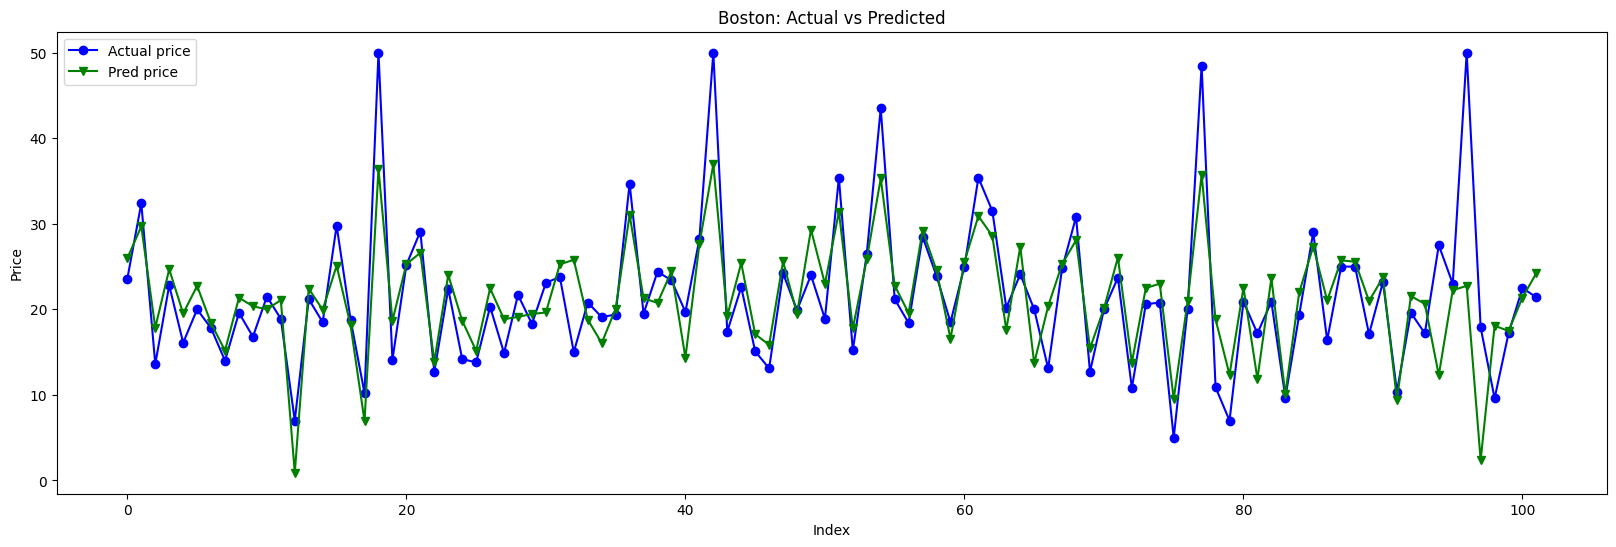

In [826]:
plt.figure(figsize=(20, 6))
plt.plot(y_test, 'o-', color="b", label="Actual price")
plt.plot(y_pred_lasso, 'v-', color='g', label="Pred price")
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Boston: Actual vs Predicted")
plt.legend()
plt.show()

In [827]:
print("基础线性回归 与 Lasso回归")
print(f"MSE 变化：{mse_linear_scaled - mse_lasso:+.4f}")
print(f"R²  变化：{r2_lasso - r2_linear_scaled:+.4f}")
print(f"Lasso 将 {total_coef - nonzero_coef} 个特征的权重降为0")

基础线性回归 与 Lasso回归
MSE 变化：-3.2866
R²  变化：-0.0448
Lasso 将 7 个特征的权重降为0


L1 正则化的特征选择能力

### 2.8 模型对比

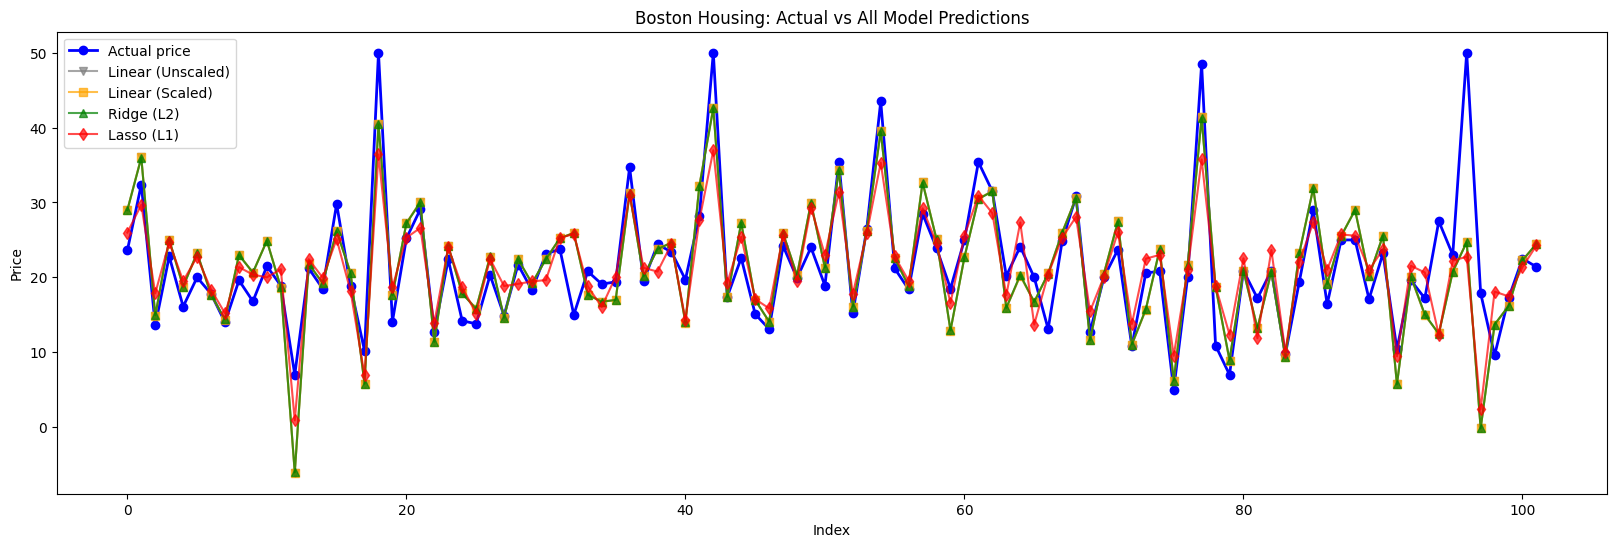

In [828]:
plt.figure(figsize=(20, 6))

# 真实值
plt.plot(y_test, 'o-', color="b", label="Actual price", linewidth=2)

# 各模型预测值
plt.plot(y_pred, 'v-', color='gray', label="Linear (Unscaled)", alpha=0.7)
plt.plot(y_pred_linear_scaled, 's-', color='orange', label="Linear (Scaled)", alpha=0.7)
plt.plot(y_pred_ridge, '^-', color='green', label="Ridge (L2)", alpha=0.7)
plt.plot(y_pred_lasso, 'd-', color='red', label="Lasso (L1)", alpha=0.7)

plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Boston Housing: Actual vs All Model Predictions")
plt.legend()
plt.show()

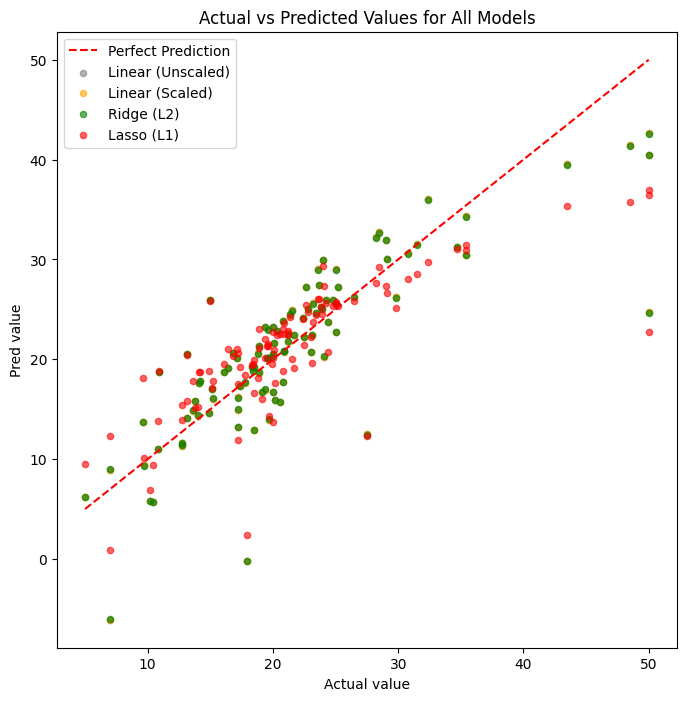

In [829]:

plt.figure(figsize=(8, 8))

# 理想参考线（y=x）
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

# 各模型预测散点图
plt.scatter(y_test, y_pred, alpha=0.6, s=20, label='Linear (Unscaled)', c='gray')
plt.scatter(y_test, y_pred_linear_scaled, alpha=0.6, s=20, label='Linear (Scaled)', c='orange')
plt.scatter(y_test, y_pred_ridge, alpha=0.6, s=20, label='Ridge (L2)', c='green')
plt.scatter(y_test, y_pred_lasso, alpha=0.6, s=20, label='Lasso (L1)', c='red')

plt.xlabel("Actual value")
plt.ylabel("Pred value")
plt.title("Actual vs Predicted Values for All Models")
plt.legend()
plt.show()

## 3. 总结

1. 归一化：归一化不影响预测结果，只加速训练
2. L2正则化：岭回归，惩罚平方和，防止过拟合
3. L1正则化：Lasso回归，实现特征选择
4. 模型评估：MSE 和 R² 是常用回归评估指标